<a href="https://colab.research.google.com/github/esthy13/cil-intrusion-detection/blob/main/new_Experience_Replay_for_Class_Incremental_IDS_UNSWNB15.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ER (Experience Replay) — UNSW-NB15 Continual Learning Baseline

Goal: Implement Experience Replay (ER) for a class-incremental IDS scenario on UNSW-NB15.
Training  tasks where attack classes appear progressively, while Normal traffic is always present.

**🔹1. Problem Setting**

this is to simulate a class incremental learning scenario for IDS using the UNSW-NB15 dataset. The goal is to study catastrophic forgetting when new attack classes are introduced over time.
example:

Task 1 → Normal + Generic

Task 2 → Normal + Generic + Exploits

Normal traffic is always present


matches real IDS evolution. Goal:
Evaluate whether Experience Replay reduces forgetting when new attack
classes are introduced.**bold text**

In [ ]:
# ===== Imports =====
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import OneHotEncoder, RobustScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, f1_score

import random

# ===== Device =====
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)


Using device: cpu


## 2.Dataset Loading
The dataset contains 45 columns, including:
- Flow-based numerical features (e.g., duration, packets, bytes)
- Categorical protocol-related features (proto, service, state)
- Two label columns:
    - `attack_cat` (multi-class attack category)
    - `label` (binary normal vs attack)

For our class-incremental learning setup, i will use `attack_cat`
as the target label.

In [ ]:
import pandas as pd


train = pd.read_csv("UNSW_NB15_training-set.csv")
test  = pd.read_csv("UNSW_NB15_testing-set.csv")

print("Train shape:", train.shape)
print("Test shape:", test.shape)

train.head()


Train shape: (175341, 45)
Test shape: (82332, 45)


,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.121478,tcp,-,FIN,6,4,258,172,74.087490,...,1,1,0,0,0,1,1,0,Normal,0
1,2,0.649902,tcp,-,FIN,14,38,734,42014,78.473372,...,1,2,0,0,0,1,6,0,Normal,0
2,3,1.623129,tcp,-,FIN,8,16,364,13186,14.170161,...,1,3,0,0,0,2,6,0,Normal,0
3,4,1.681642,tcp,ftp,FIN,12,12,628,770,13.677108,...,1,3,1,1,0,2,1,0,Normal,0
4,5,0.449454,tcp,-,FIN,10,6,534,268,33.373826,...,1,40,0,0,0,2,39,0,Normal,0


## 3.Class-Incremental Task Scenario Definition

To simulate a realistic evolving threat environment, defining
a class-incremental learning (CIL) scenario.

- Task 1: The model is trained on Normal + Generic traffic.
- Task 2: A new attack class (Exploits) is introduced,
  while previously seen classes remain present.

This setup mimics real-world IDS deployment, where new attack
types appear over time and the model must adapt without
forgetting previously learned patterns.


In [ ]:
# Task scenario (using the example i mentioned)
NORMAL = "Normal"
attack_order = ["Generic", "Exploits", "Fuzzers", "DoS", "Reconnaissance",
                "Analysis", "Backdoor", "Shellcode", "Worms"]

# just an example: Task1 -> Task2
# [1,1]
scenario_1plus1 = [
    [NORMAL, "Generic"],                 # Task 1 classes
    [NORMAL, "Generic", "Exploits"],     # Task 2 classes
]

def build_task_df(df, classes):
    """Filter dataframe to only the given attack_cat classes."""
    return df[df["attack_cat"].isin(classes)].copy()

# Build task datasets
task1_train = build_task_df(train, scenario_1plus1[0])
task1_test  = build_task_df(test,  scenario_1plus1[0])

task2_train = build_task_df(train, scenario_1plus1[1])
task2_test  = build_task_df(test,  scenario_1plus1[1])

print("Task 1 train shape:", task1_train.shape)
print("Task 1 test shape: ", task1_test.shape)
print("Task 2 train shape:", task2_train.shape)
print("Task 2 test shape: ", task2_test.shape)

print("\nTask 1 class counts:\n", task1_train["attack_cat"].value_counts())
print("\nTask 2 class counts:\n", task2_train["attack_cat"].value_counts())


Task 1 train shape: (96000, 45)
Task 1 test shape:  (55871, 45)
Task 2 train shape: (129393, 45)
Task 2 test shape:  (67003, 45)

Task 1 class counts:
 attack_cat
Normal     56000
Generic    40000
Name: count, dtype: int64

Task 2 class counts:
 attack_cat
Normal      56000
Generic     40000
Exploits    33393
Name: count, dtype: int64


**4. Feature Selection**

I  removed non-feature columns (id, attack_cat, label), and separated categorical and numerical features.

Before training the model, separate input features from labels.

removing:
- `id` → Identifier (not informative for learning)
- `attack_cat` → Multi-class label (used as target)
- `label` → Binary label (not used in this multi-class CIL setup)

The remaining columns form the feature space used by the model.

removing the non-informative or target columns. The model should only see feature values, not labels or identifiers. This leaves us with 42 raw features.
Why drop the binary label?
Because we are solving a multi-class incremental problem using attack_cat, not binary classification.

In [ ]:
#After removing three columns from the original 45, we obtain 42 feature columns before encoding.
# Columns to drop
# Columns to drop (not input features)
drop_cols = ["id", "attack_cat", "label"]

# Remaining columns are model features
feature_cols = [c for c in train.columns if c not in drop_cols]

print("Number of feature columns:", len(feature_cols))
print(feature_cols[:10])


Number of feature columns: 42
['dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sttl']


In [ ]:
print("Categorical columns present:",
      all(col in feature_cols for col in ["proto", "service", "state"]))


Categorical columns present: True


In [ ]:
import numpy as np

def to_dense_array(X):
    return X.toarray() if hasattr(X, "toarray") else np.asarray(X)

# Transform Task 1 using the preprocessor (already fit on task1_train)
X1_train_np = to_dense_array(preprocessor.transform(task1_train[feature_cols]))
X1_test_np  = to_dense_array(preprocessor.transform(task1_test[feature_cols]))

input_dim = X1_train_np.shape[1]
print("Input dim:", input_dim)


Input dim: 186


We use a two-hidden-layer MLP for classification. The input dimension is 186 after preprocessing. The output layer size corresponds to the number of classes at each task. ReLU activations are used in hidden layers and raw logits are passed to CrossEntropyLoss.

In [ ]:
import torch.nn as nn
import torch.nn.functional as F

class MLPIDS(nn.Module):   #This is your Intrusion Detection Model. It is a simple Multi-Layer Perceptron (MLP)
    def __init__(self, input_dim: int, num_classes: int):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, 256)
        self.fc2 = nn.Linear(256, 128)
        self.out = nn.Linear(128, num_classes)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.out(x)

model = MLPIDS(input_dim=input_dim, num_classes=num_classes_task1).to(device)
print(model)


MLPIDS(
  (fc1): Linear(in_features=186, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (out): Linear(in_features=128, out_features=2, bias=True)
)


In [ ]:
from sklearn.preprocessing import LabelEncoder
import numpy as np

le1 = LabelEncoder()
le1.fit(task1_train["attack_cat"])

y1_train = le1.transform(task1_train["attack_cat"])
y1_test  = le1.transform(task1_test["attack_cat"])

print("Task1 classes:", list(le1.classes_))
print("Unique y1 labels:", np.unique(y1_train))


Task1 classes: ['Generic', 'Normal']
Unique y1 labels: [0 1]


## 6. Feature Encoding and Scaling
 applying a preprocessing pipeline consisting of:

- OneHotEncoder for categorical protocol-related features:
  - `proto`
  - `service`
  - `state`

- RobustScaler for numerical features.

RobustScaler is chosen because network traffic features are often
heavy tailed and contains extreme values. It is more stable than
StandardScaler in this context.

To preserve class incremental learning realism, the preprocessing
pipeline is fitted only on Task 1 training data.


In [ ]:
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.compose import ColumnTransformer

categorical_cols = ["proto", "service", "state"]
numeric_cols = [c for c in feature_cols if c not in categorical_cols]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", RobustScaler(), numeric_cols),
    ]
)

# Fit ONLY on Task1 training data (important for CIL realism)
preprocessor.fit(task1_train[feature_cols])

print("Preprocessor fitted on Task1.")

preprocessor.fit(task1_train[feature_cols])


Preprocessor fitted on Task1.


ColumnTransformer(transformers=[('cat', OneHotEncoder(handle_unknown='ignore'),
                                 ['proto', 'service', 'state']),
                                ('num', RobustScaler(),
                                 ['dur', 'spkts', 'dpkts', 'sbytes', 'dbytes',
                                  'rate', 'sttl', 'dttl', 'sload', 'dload',
                                  'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit',
                                  'djit', 'swin', 'stcpb', 'dtcpb', 'dwin',
                                  'tcprtt', 'synack', 'ackdat', 'smean',
                                  'dmean', 'trans_depth', 'response_body_len',
                                  'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm', ...])])

## 7. Transform Task Data into Model Inputs

 applying the preprocessing pipeline to convert each task dataset into
numerical model inputs.

- The transformer output may be sparse (due to one-hot encoding),
  so we convert it into a dense NumPy array for PyTorch.
- We record the final input dimension (`input_dim`) which defines the
  neural network input layer size.


In [ ]:
import numpy as np

def to_dense_array(X):
    return X.toarray() if hasattr(X, "toarray") else np.asarray(X)

# Transform Task 1 using the fitted preprocessor
X1_train_np = to_dense_array(preprocessor.transform(task1_train[feature_cols]))
X1_test_np  = to_dense_array(preprocessor.transform(task1_test[feature_cols]))

input_dim = X1_train_np.shape[1]
print("Task1 X train shape:", X1_train_np.shape)
print("Task1 X test shape: ", X1_test_np.shape)
print("Input dim:", input_dim)



Task1 X train shape: (96000, 186)
Task1 X test shape:  (55871, 186)
Input dim: 186


## 8. Label Encoding for Task 1

For Task 1, encode attack categories into integer labels
using LabelEncoder.
Since Task 1 contains only:
- Generic
- Normal
the model output layer will initially have 2 classes.

This mapping ensures that labels are in the range [0, C-1],
which is required for CrossEntropyLoss in PyTorch.
Why not use the same encoder for all tasks?

Because at this stage the model has only seen Task1 classes. Later, when Task2 introduces a new class, we expand the classifier and update the mapping.


In [ ]:
from sklearn.preprocessing import LabelEncoder
import numpy as np

le1 = LabelEncoder()
le1.fit(task1_train["attack_cat"])

y1_train = le1.transform(task1_train["attack_cat"])
y1_test  = le1.transform(task1_test["attack_cat"])

print("Task1 classes:", list(le1.classes_))
print("Counts:", np.bincount(y1_train))


Task1 classes: ['Generic', 'Normal']
Counts: [40000 56000]


In [ ]:
from sklearn.preprocessing import LabelEncoder
import numpy as np

le1 = LabelEncoder()
le1.fit(task1_train["attack_cat"])

y1_train = le1.transform(task1_train["attack_cat"])
y1_test  = le1.transform(task1_test["attack_cat"])

num_classes_task1 = len(le1.classes_)

print("Task1 classes:", list(le1.classes_))
print("Counts:", np.bincount(y1_train))
print("Number of classes (Task1):", num_classes_task1)


Task1 classes: ['Generic', 'Normal']
Counts: [40000 56000]
Number of classes (Task1): 2


## 9. PyTorch Dataset and DataLoader (Task 1)
converting the preprocessed NumPy arrays into PyTorch tensors.
- Features are stored as float32 tensors.
- Labels are stored as long tensors (required for CrossEntropyLoss).

then creating a
- A training DataLoader (with shuffling)
- A test DataLoader (without shuffling)

Batch size is set to 256.


In [ ]:
import torch
from torch.utils.data import TensorDataset, DataLoader

batch_size = 256

train_ds1 = TensorDataset(
    torch.tensor(X1_train_np, dtype=torch.float32),
    torch.tensor(y1_train, dtype=torch.long)
)
test_ds1 = TensorDataset(
    torch.tensor(X1_test_np, dtype=torch.float32),
    torch.tensor(y1_test, dtype=torch.long)
)

train_loader1 = DataLoader(train_ds1, batch_size=batch_size, shuffle=True)
test_loader1  = DataLoader(test_ds1, batch_size=batch_size, shuffle=False)



In [ ]:
import torch
from torch.utils.data import TensorDataset, DataLoader

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

batch_size = 256

train_ds1 = TensorDataset(
    torch.tensor(X1_train_np, dtype=torch.float32),
    torch.tensor(y1_train, dtype=torch.long)
)

test_ds1 = TensorDataset(
    torch.tensor(X1_test_np, dtype=torch.float32),
    torch.tensor(y1_test, dtype=torch.long)
)

train_loader1 = DataLoader(train_ds1, batch_size=batch_size, shuffle=True)
test_loader1  = DataLoader(test_ds1, batch_size=batch_size, shuffle=False)

print("Task1 train batches:", len(train_loader1))


Device: cpu
Task1 train batches: 375


In [ ]:
import torch.nn as nn
import torch.nn.functional as F

class MLPIDS(nn.Module):
    def __init__(self, input_dim: int, num_classes: int):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, 256)
        self.fc2 = nn.Linear(256, 128)
        self.out = nn.Linear(128, num_classes)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.out(x)


In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score, f1_score

def evaluate(model, loader, device):
    model.eval()
    all_preds, all_targets = [], []

    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            preds = torch.argmax(logits, dim=1)
            all_preds.append(preds.cpu().numpy())
            all_targets.append(yb.cpu().numpy())

    all_preds = np.concatenate(all_preds)
    all_targets = np.concatenate(all_targets)

    acc = accuracy_score(all_targets, all_preds)
    f1 = f1_score(all_targets, all_preds, average="macro")
    return acc, f1


def train_one_task(model, train_loader, test_loader, device, y_train_for_weights, epochs=3, lr=1e-4):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    # class weights to handle imbalance
    counts = np.bincount(y_train_for_weights)
    weights = (counts.sum() / (len(counts) * counts)).astype(np.float32)
    weights = torch.tensor(weights, dtype=torch.float32).to(device)

    loss_fn = nn.CrossEntropyLoss(weight=weights)

    history = []
    for epoch in range(1, epochs + 1):
        model.train()
        total_loss = 0.0

        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            logits = model(xb)
            loss = loss_fn(logits, yb)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        avg_loss = total_loss / len(train_loader)
        acc, f1 = evaluate(model, test_loader, device)
        print(f"Epoch {epoch}/{epochs} | Loss: {avg_loss:.4f} | Test Acc: {acc:.4f} | Test Macro-F1: {f1:.4f}")
        history.append({"epoch": epoch, "loss": float(avg_loss), "acc": float(acc), "macro_f1": float(f1)})

    return model, history


In [ ]:
# Initialize model for Task 1 (2 classes)
model = MLPIDS(input_dim=input_dim, num_classes=num_classes_task1).to(device)
print(model)

# Train Task 1
model, hist_task1 = train_one_task(
    model=model,
    train_loader=train_loader1,
    test_loader=test_loader1,
    device=device,
    y_train_for_weights=y1_train,
    epochs=3,
    lr=1e-4
)


MLPIDS(
  (fc1): Linear(in_features=186, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (out): Linear(in_features=128, out_features=2, bias=True)
)
Epoch 1/3 | Loss: 2.5280 | Test Acc: 0.9315 | Test Macro-F1: 0.9258
Epoch 2/3 | Loss: 1.9563 | Test Acc: 0.9692 | Test Macro-F1: 0.9658
Epoch 3/3 | Loss: 1.4727 | Test Acc: 0.9819 | Test Macro-F1: 0.9797


In [ ]:
# Transform Task 2 (using the SAME preprocessor fitted on Task1)
X2_train_np = to_dense_array(preprocessor.transform(task2_train[feature_cols]))
X2_test_np  = to_dense_array(preprocessor.transform(task2_test[feature_cols]))

print("Task2 X train shape:", X2_train_np.shape)
print("Task2 X test shape: ", X2_test_np.shape)


Task2 X train shape: (129393, 186)
Task2 X test shape:  (67003, 186)


In [ ]:
from sklearn.preprocessing import LabelEncoder
import numpy as np

le2 = LabelEncoder()
le2.fit(task2_train["attack_cat"])

y2_train = le2.transform(task2_train["attack_cat"])
y2_test  = le2.transform(task2_test["attack_cat"])

num_classes_task2 = len(le2.classes_)

print("Task2 classes:", list(le2.classes_))
print("Unique y2 labels:", np.unique(y2_train))
print("Number of classes (Task2):", num_classes_task2)


Task2 classes: ['Exploits', 'Generic', 'Normal']
Unique y2 labels: [0 1 2]
Number of classes (Task2): 3


In [ ]:
from torch.utils.data import TensorDataset, DataLoader
import torch

train_ds2 = TensorDataset(
    torch.tensor(X2_train_np, dtype=torch.float32),
    torch.tensor(y2_train, dtype=torch.long)
)

test_ds2 = TensorDataset(
    torch.tensor(X2_test_np, dtype=torch.float32),
    torch.tensor(y2_test, dtype=torch.long)
)

train_loader2 = DataLoader(train_ds2, batch_size=256, shuffle=True)
test_loader2  = DataLoader(test_ds2, batch_size=256, shuffle=False)

print("Task2 train batches:", len(train_loader2))


Task2 train batches: 506


In [ ]:
import torch
import torch.nn as nn

def expand_output_layer(model, new_num_classes):
    old_out = model.out
    old_num_classes = old_out.out_features

    # If already large enough, do nothing
    if new_num_classes <= old_num_classes:
        return model

    # Create new output layer
    new_out = nn.Linear(old_out.in_features, new_num_classes)

    # Copy old weights/bias into new layer (keep learned classes)
    with torch.no_grad():
        new_out.weight[:old_num_classes] = old_out.weight
        new_out.bias[:old_num_classes] = old_out.bias

    model.out = new_out.to(next(model.parameters()).device)
    return model

# Expand for Task 2
model = expand_output_layer(model, new_num_classes=num_classes_task2)

print("Expanded output classes:", model.out.out_features)


Expanded output classes: 3


In [ ]:
acc_t1_before, f1_t1_before = evaluate(model, test_loader1, device)
print("Before Task2 training | Task1 Test Acc:", acc_t1_before, "| Macro-F1:", f1_t1_before)


Before Task2 training | Task1 Test Acc: 0.9622523312630882 | Macro-F1: 0.6483217069496323


In [ ]:
model, hist_task2_no_er = train_one_task(
    model=model,
    train_loader=train_loader2,
    test_loader=test_loader2,
    device=device,
    y_train_for_weights=y2_train,
    epochs=3,
    lr=1e-4
)


Epoch 1/3 | Loss: 5.5616 | Test Acc: 0.7839 | Test Macro-F1: 0.7577
Epoch 2/3 | Loss: 2.3552 | Test Acc: 0.7389 | Test Macro-F1: 0.7413
Epoch 3/3 | Loss: 3.8628 | Test Acc: 0.8052 | Test Macro-F1: 0.7984


In [ ]:
acc_t1_after, f1_t1_after = evaluate(model, test_loader1, device)
print("After Task2 training (NO ER) | Task1 Acc:", acc_t1_after, "| Macro-F1:", f1_t1_after)

forgetting_no_er = f1_t1_before - f1_t1_after
print("Forgetting (NO ER) =", forgetting_no_er)


After Task2 training (NO ER) | Task1 Acc: 0.024628161300137816 | Macro-F1: 0.02217569648674445
Forgetting (NO ER) = 0.6261460104628879


In [ ]:
import random
import torch

class ReplayBuffer:
    def __init__(self, capacity):
        self.capacity = capacity
        self.X = None
        self.y = None
        self.n_seen = 0  # how many samples seen total (for reservoir sampling)

    def add(self, X_np, y_np):
        """
        Reservoir sampling: keeps a uniform sample of all seen items.
        X_np: (N, D) numpy array
        y_np: (N,) numpy array
        """
        if self.X is None:
            self.X = np.empty((0, X_np.shape[1]), dtype=np.float32)
            self.y = np.empty((0,), dtype=np.int64)

        for i in range(len(y_np)):
            self.n_seen += 1
            if len(self.y) < self.capacity:
                # append until full
                self.X = np.vstack([self.X, X_np[i:i+1]])
                self.y = np.append(self.y, y_np[i])
            else:
                # replace with probability capacity/n_seen
                j = random.randint(0, self.n_seen - 1)
                if j < self.capacity:
                    self.X[j] = X_np[i]
                    self.y[j] = y_np[i]

    def sample(self, batch_size, device):
        if self.y is None or len(self.y) == 0:
            return None, None
        idx = np.random.choice(len(self.y), size=min(batch_size, len(self.y)), replace=False)
        xb = torch.tensor(self.X[idx], dtype=torch.float32, device=device)
        yb = torch.tensor(self.y[idx], dtype=torch.long, device=device)
        return xb, yb

    def __len__(self):
        return 0 if self.y is None else len(self.y)


In [ ]:
memory_size = 20000
replay_batch_size = 256

buffer = ReplayBuffer(capacity=memory_size)
buffer.add(X1_train_np, y1_train)

print("Replay buffer size:", len(buffer))


Replay buffer size: 20000


In [ ]:
def train_task_with_er(
    model,
    train_loader,
    test_loader,
    device,
    buffer,
    y_train_for_weights,
    epochs=3,
    lr=1e-4,
    replay_batch_size=256
):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    # class weights (imbalance)
    counts = np.bincount(y_train_for_weights)
    weights = (counts.sum() / (len(counts) * counts)).astype(np.float32)
    weights = torch.tensor(weights, dtype=torch.float32).to(device)
    loss_fn = nn.CrossEntropyLoss(weight=weights)

    history = []
    for epoch in range(1, epochs + 1):
        model.train()
        total_loss = 0.0

        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)

            # sample replay and mix
            xr, yr = buffer.sample(replay_batch_size, device)
            if xr is not None:
                xb = torch.cat([xb, xr], dim=0)
                yb = torch.cat([yb, yr], dim=0)

            optimizer.zero_grad()
            logits = model(xb)
            loss = loss_fn(logits, yb)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        avg_loss = total_loss / len(train_loader)
        acc, f1 = evaluate(model, test_loader, device)
        print(f"[ER] Epoch {epoch}/{epochs} | Loss: {avg_loss:.4f} | Task Test Acc: {acc:.4f} | Macro-F1: {f1:.4f}")
        history.append({"epoch": epoch, "loss": float(avg_loss), "acc": float(acc), "macro_f1": float(f1)})

    return model, history


In [ ]:
# 1) Re-train Task1 from scratch (fresh model)
model_er = MLPIDS(input_dim=input_dim, num_classes=num_classes_task1).to(device)
model_er, _ = train_one_task(
    model=model_er,
    train_loader=train_loader1,
    test_loader=test_loader1,
    device=device,
    y_train_for_weights=y1_train,
    epochs=3,
    lr=1e-4
)

# 2) Expand output to Task2 classes (3)
model_er = expand_output_layer(model_er, new_num_classes=num_classes_task2)

# 3) Measure Task1 BEFORE Task2 (for forgetting baseline)
acc_er_before, f1_er_before = evaluate(model_er, test_loader1, device)
print("Before ER Task2 | Task1 Acc:", acc_er_before, "| Macro-F1:", f1_er_before)

# 4) Train Task2 WITH ER
model_er, _ = train_task_with_er(
    model=model_er,
    train_loader=train_loader2,
    test_loader=test_loader2,
    device=device,
    buffer=buffer,
    y_train_for_weights=y2_train,
    epochs=3,
    lr=1e-4,
    replay_batch_size=replay_batch_size
)

# 5) Measure Task1 AFTER Task2 and compute forgetting
acc_er_after, f1_er_after = evaluate(model_er, test_loader1, device)
print("After ER Task2 | Task1 Acc:", acc_er_after, "| Macro-F1:", f1_er_after)

forgetting_er = f1_er_before - f1_er_after
print("Forgetting WITH ER =", forgetting_er)


Epoch 1/3 | Loss: 1.6355 | Test Acc: 0.9500 | Test Macro-F1: 0.9451
Epoch 2/3 | Loss: 1.9145 | Test Acc: 0.9796 | Test Macro-F1: 0.9772
Epoch 3/3 | Loss: 1.9195 | Test Acc: 0.9852 | Test Macro-F1: 0.9833
Before ER Task2 | Task1 Acc: 0.7048916253512556 | Macro-F1: 0.5680875219343826
[ER] Epoch 1/3 | Loss: 2.3265 | Task Test Acc: 0.1555 | Macro-F1: 0.1666
[ER] Epoch 2/3 | Loss: 2.4061 | Task Test Acc: 0.1392 | Macro-F1: 0.1534
[ER] Epoch 3/3 | Loss: 2.1041 | Task Test Acc: 0.1621 | Macro-F1: 0.1734
After ER Task2 | Task1 Acc: 0.9215335326018865 | Macro-F1: 0.620146926936914
Forgetting WITH ER = -0.05205940500253137


In [ ]:
import os
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

os.makedirs("artifacts", exist_ok=True)

def plot_and_save_confusion(model, loader, device, class_names, title, save_path):
    model.eval()
    all_preds, all_targets = [], []

    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            preds = torch.argmax(logits, dim=1)
            all_preds.append(preds.cpu().numpy())
            all_targets.append(yb.cpu().numpy())

    all_preds = np.concatenate(all_preds)
    all_targets = np.concatenate(all_targets)

    cm = confusion_matrix(all_targets, all_preds, labels=list(range(len(class_names))))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

    fig, ax = plt.subplots(figsize=(6, 6))
    disp.plot(ax=ax, cmap=None, values_format="d", colorbar=False)
    ax.set_title(title)
    plt.tight_layout()
    plt.savefig(save_path, dpi=200)
    plt.close(fig)

    print("Saved:", save_path)
    return cm


In [ ]:
cm_task1_no_er = plot_and_save_confusion(
    model=model,                    # baseline model (no ER)
    loader=test_loader1,
    device=device,
    class_names=list(le1.classes_),  # Task1 class names
    title="Task1 Confusion Matrix (No ER)",
    save_path="artifacts/cm_task1_no_er.png"
)


Saved: artifacts/cm_task1_no_er.png


In [ ]:
cm_task1_er = plot_and_save_confusion(
    model=model_er,                 # ER model
    loader=test_loader1,
    device=device,
    class_names=list(le1.classes_), # Task1 class names
    title="Task1 Confusion Matrix (With ER)",
    save_path="artifacts/cm_task1_er.png"
)


Saved: artifacts/cm_task1_er.png


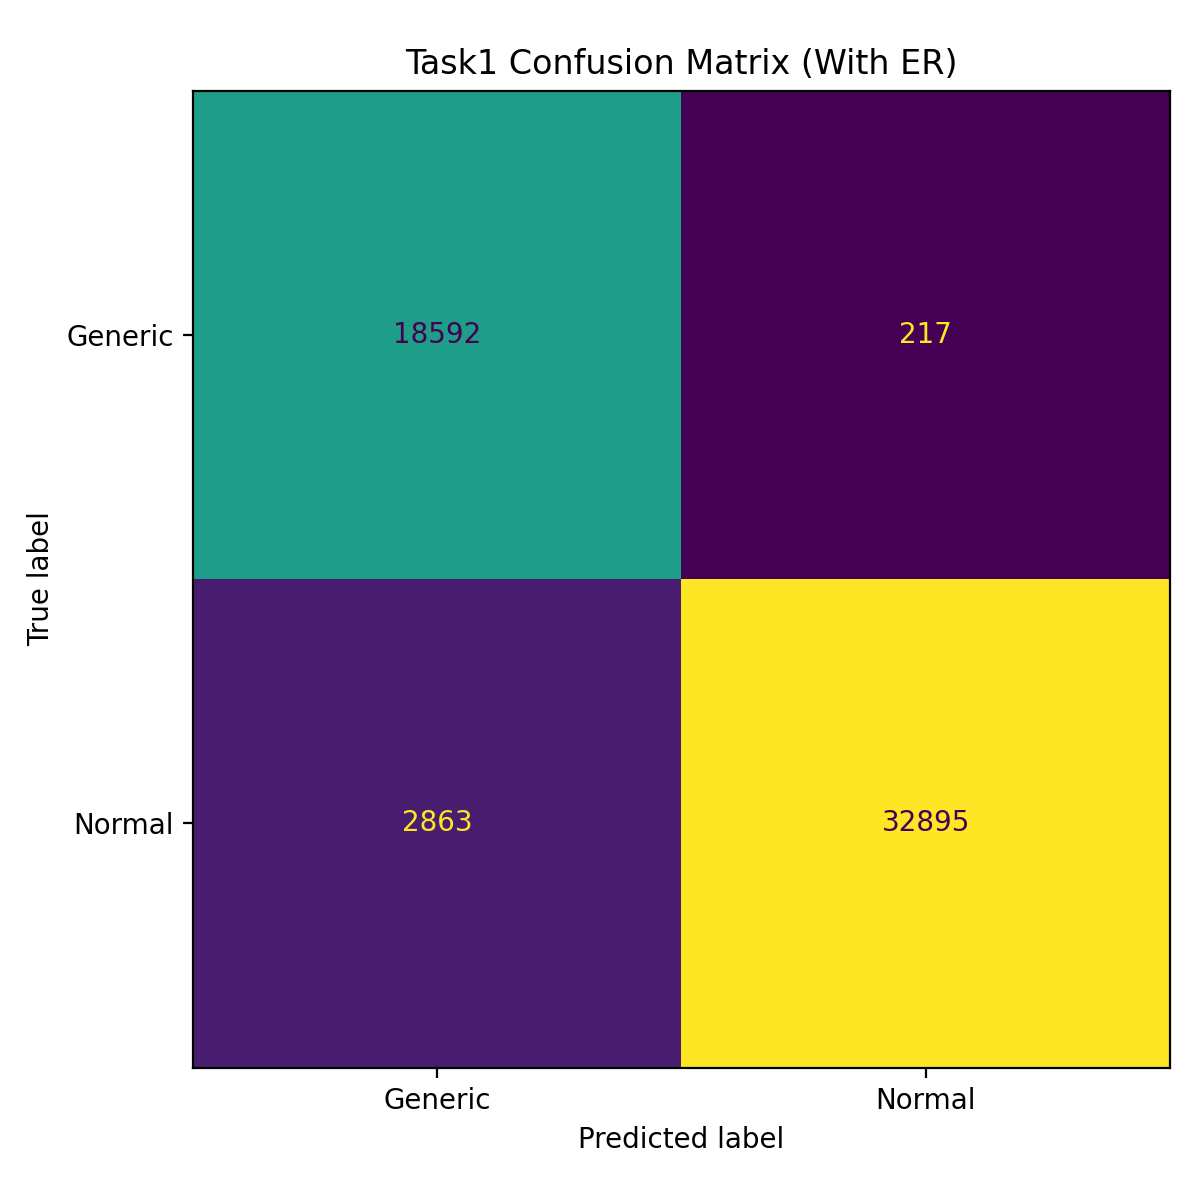

In [ ]:
from IPython.display import Image, display
display(Image("artifacts/cm_task1_er.png"))


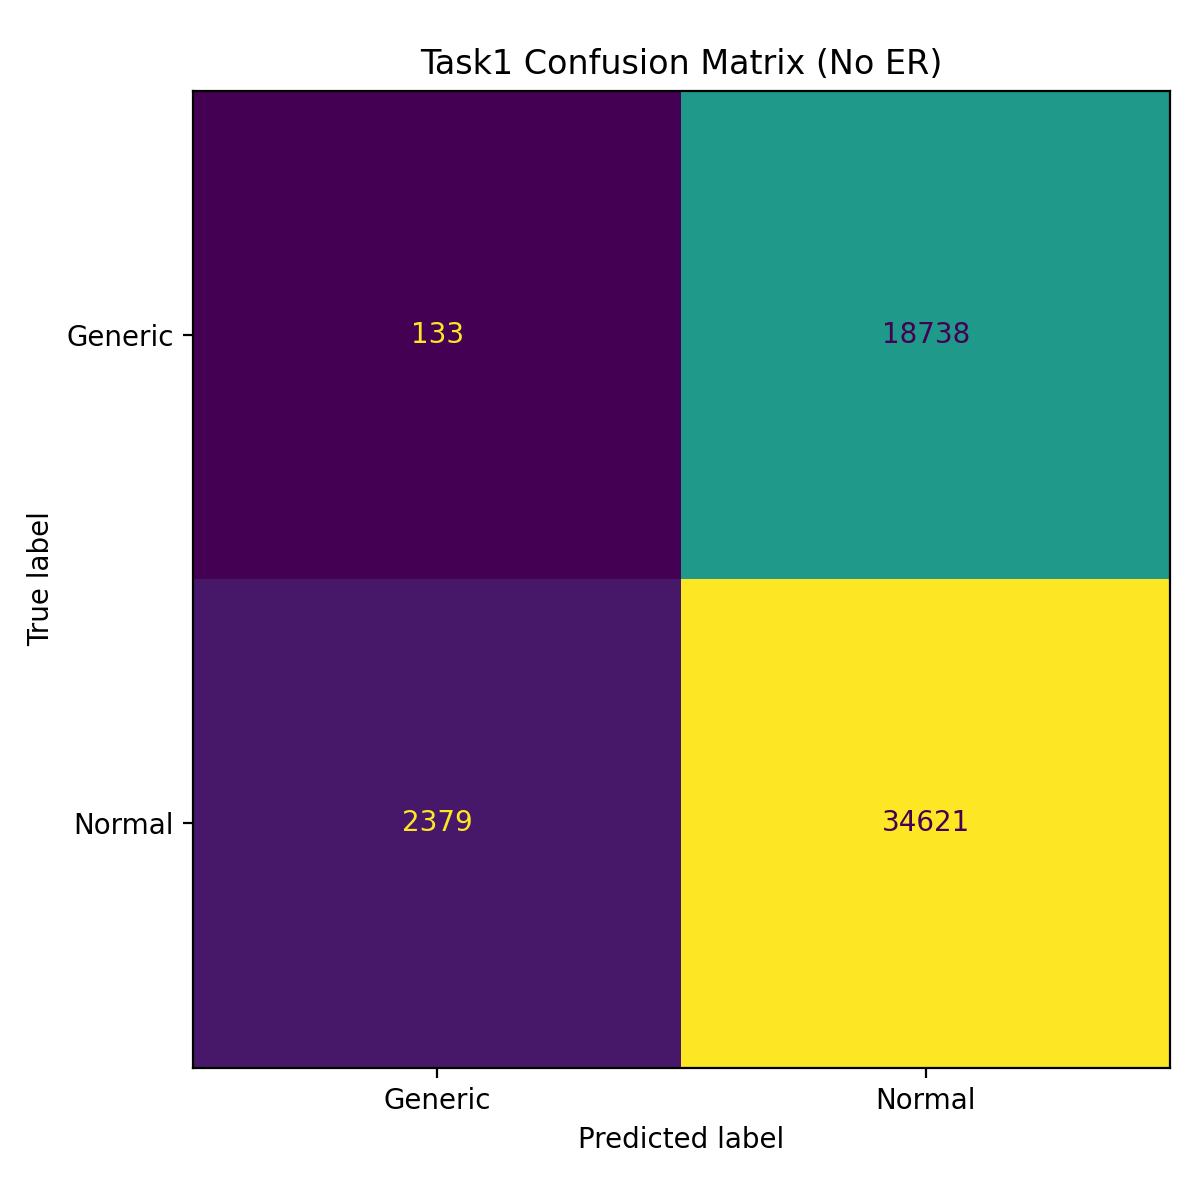

In [ ]:
from IPython.display import Image, display
display(Image("artifacts/cm_task1_no_er.png"))


In [ ]:
cm_task2_er = plot_and_save_confusion(
    model=model_er,
    loader=test_loader2,
    device=device,
    class_names=list(le2.classes_),  # Task2 class names (3)
    title="Task2 Confusion Matrix (With ER)",
    save_path="artifacts/cm_task2_er.png"
)


Saved: artifacts/cm_task2_er.png


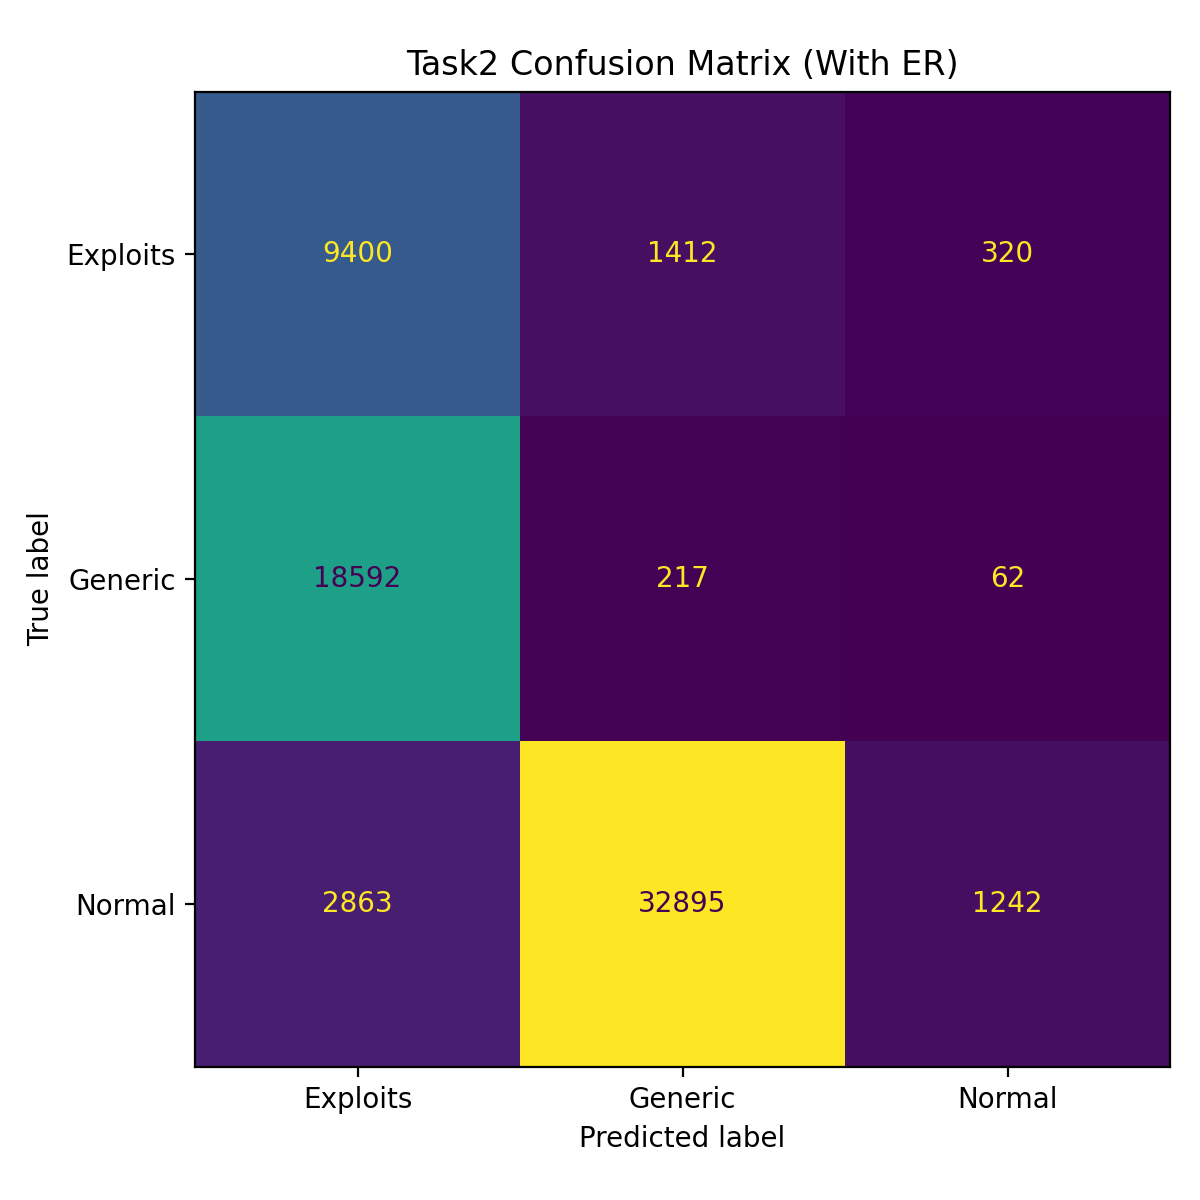

In [ ]:
from IPython.display import Image, display
display(Image("artifacts/cm_task2_er.png"))



In [ ]:
import json
import os

os.makedirs("artifacts", exist_ok=True)

results = {
    "dataset": "UNSW-NB15",
    "scenario": {
        "task1_classes": scenario_1plus1[0],
        "task2_classes": scenario_1plus1[1],
    },
    "metrics": {
        "task1_final": {
            "macro_f1": float(hist_task1[-1]["macro_f1"]) if "hist_task1" in globals() else None,
            "acc": float(hist_task1[-1]["acc"]) if "hist_task1" in globals() else None,
        },
        "forgetting": {
            "no_er": float(forgetting_no_er) if "forgetting_no_er" in globals() else None,
            "with_er": float(forgetting_er) if "forgetting_er" in globals() else None,
        },
        "task1_before_task2": {
            "no_er_macro_f1": float(f1_t1_before) if "f1_t1_before" in globals() else None,
            "no_er_after_macro_f1": float(f1_t1_after) if "f1_t1_after" in globals() else None,
            "er_before_macro_f1": float(f1_er_before) if "f1_er_before" in globals() else None,
            "er_after_macro_f1": float(f1_er_after) if "f1_er_after" in globals() else None,
        }
    },
    "artifacts": {
        "confusion_matrices": {
            "task1_no_er": "artifacts/cm_task1_no_er.png",
            "task1_er": "artifacts/cm_task1_er.png",
            "task2_er": "artifacts/cm_task2_er.png",
        }
    }
}

with open("artifacts/run_results.json", "w") as f:
    json.dump(results, f, indent=2)

print("Saved JSON: artifacts/run_results.json")


Saved JSON: artifacts/run_results.json


In [ ]:
with open("artifacts/run_results.json", "r") as f:
    print(f.read())


{
  "dataset": "UNSW-NB15",
  "scenario": {
    "task1_classes": [
      "Normal",
      "Generic"
    ],
    "task2_classes": [
      "Normal",
      "Generic",
      "Exploits"
    ]
  },
  "metrics": {
    "task1_final": {
      "macro_f1": 0.9796557219191011,
      "acc": 0.9818689481126166
    },
    "forgetting": {
      "no_er": 0.6261460104628879,
      "with_er": -0.05205940500253137
    },
    "task1_before_task2": {
      "no_er_macro_f1": 0.6483217069496323,
      "no_er_after_macro_f1": 0.02217569648674445,
      "er_before_macro_f1": 0.5680875219343826,
      "er_after_macro_f1": 0.620146926936914
    }
  },
  "artifacts": {
    "confusion_matrices": {
      "task1_no_er": "artifacts/cm_task1_no_er.png",
      "task1_er": "artifacts/cm_task1_er.png",
      "task2_er": "artifacts/cm_task2_er.png"
    }
  }
}


In [ ]:
# --- Evaluate NO-ER model ---
acc_t1_no_er, f1_t1_no_er = evaluate(model, test_loader1, device)
acc_t2_no_er, f1_t2_no_er = evaluate(model, test_loader2, device)

avg_acc_no_er = (acc_t1_no_er + acc_t2_no_er) / 2
avg_f1_no_er  = (f1_t1_no_er  + f1_t2_no_er) / 2

print("[NO ER] Task1 Acc/F1:", acc_t1_no_er, f1_t1_no_er)
print("[NO ER] Task2 Acc/F1:", acc_t2_no_er, f1_t2_no_er)
print("[NO ER] Avg Acc:", avg_acc_no_er, "| Avg Macro-F1:", avg_f1_no_er)

# --- Evaluate ER model ---
acc_t1_er, f1_t1_er = evaluate(model_er, test_loader1, device)
acc_t2_er, f1_t2_er = evaluate(model_er, test_loader2, device)

avg_acc_er = (acc_t1_er + acc_t2_er) / 2
avg_f1_er  = (f1_t1_er  + f1_t2_er) / 2

print("\n[ER] Task1 Acc/F1:", acc_t1_er, f1_t1_er)
print("[ER] Task2 Acc/F1:", acc_t2_er, f1_t2_er)
print("[ER] Avg Acc:", avg_acc_er, "| Avg Macro-F1:", avg_f1_er)


[NO ER] Task1 Acc/F1: 0.6220400565588587 0.389369331553331
[NO ER] Task2 Acc/F1: 0.2964941868274555 0.20281509152081126
[NO ER] Avg Acc: 0.4592671216931571 | Avg Macro-F1: 0.2960922115370711

[ER] Task1 Acc/F1: 0.9215335326018865 0.620146926936914
[ER] Task2 Acc/F1: 0.16206737011775593 0.17339936193588956
[ER] Avg Acc: 0.5418004513598212 | Avg Macro-F1: 0.39677314443640177


In [ ]:
import json

with open("artifacts/run_results.json", "r") as f:
    results = json.load(f)

results["metrics"]["average_over_tasks"] = {
    "no_er": {"avg_acc": float(avg_acc_no_er), "avg_macro_f1": float(avg_f1_no_er)},
    "er":    {"avg_acc": float(avg_acc_er),    "avg_macro_f1": float(avg_f1_er)},
}

with open("artifacts/run_results.json", "w") as f:
    json.dump(results, f, indent=2)

print("Updated JSON with averages: artifacts/run_results.json")


Updated JSON with averages: artifacts/run_results.json


In [ ]:
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.compose import ColumnTransformer
import numpy as np

categorical_cols = ["proto", "service", "state"]
numeric_cols = [c for c in feature_cols if c not in categorical_cols]

preprocessor_minmax = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", MinMaxScaler(), numeric_cols),
    ]
)

# Fit ONLY on Task1 train (CIL realism)
preprocessor_minmax.fit(task1_train[feature_cols])

print("MinMax preprocessor fitted on Task1.")


MinMax preprocessor fitted on Task1.


In [ ]:
def to_dense_array(X):
    return X.toarray() if hasattr(X, "toarray") else np.asarray(X)

X1_train_mm = to_dense_array(preprocessor_minmax.transform(task1_train[feature_cols]))
X1_test_mm  = to_dense_array(preprocessor_minmax.transform(task1_test[feature_cols]))

X2_train_mm = to_dense_array(preprocessor_minmax.transform(task2_train[feature_cols]))
X2_test_mm  = to_dense_array(preprocessor_minmax.transform(task2_test[feature_cols]))

print("Task1 MinMax shape:", X1_train_mm.shape)
print("Task2 MinMax shape:", X2_train_mm.shape)
print("Input dim MinMax:", X1_train_mm.shape[1])


Task1 MinMax shape: (96000, 186)
Task2 MinMax shape: (129393, 186)
Input dim MinMax: 186


In [ ]:
import random
import numpy as np
import torch

class IndexReplayBuffer:
    def __init__(self, capacity: int):
        self.capacity = capacity
        self.indices = []
        self.n_seen = 0  # for reservoir sampling

    def add_indices(self, new_indices):
        """Reservoir sampling over indices."""
        for idx in new_indices:
            self.n_seen += 1
            if len(self.indices) < self.capacity:
                self.indices.append(int(idx))
            else:
                j = random.randint(0, self.n_seen - 1)
                if j < self.capacity:
                    self.indices[j] = int(idx)

    def sample(self, batch_size: int):
        if len(self.indices) == 0:
            return []
        k = min(batch_size, len(self.indices))
        return random.sample(self.indices, k)

    def __len__(self):
        return len(self.indices)


In [ ]:
memory_size = 20000
buffer_idx = IndexReplayBuffer(capacity=memory_size)

# Add indices [0 ... len(train_ds1)-1]
buffer_idx.add_indices(range(len(train_ds1)))

print("Index replay buffer size:", len(buffer_idx))
print("Example indices:", buffer_idx.indices[:10])


Index replay buffer size: 20000
Example indices: [36942, 92459, 66188, 3, 4, 34140, 92476, 69597, 23339, 71061]


In [ ]:
def sample_replay_from_indices(train_ds, index_buffer, batch_size, device):
    """Fetch replay samples by indices from the original dataset."""
    idxs = index_buffer.sample(batch_size)
    if len(idxs) == 0:
        return None, None

    xs, ys = [], []
    for i in idxs:
        x_i, y_i = train_ds[i]          # <-- pulls from original dataset
        xs.append(x_i.unsqueeze(0))
        ys.append(torch.tensor([y_i], dtype=torch.long))

    xr = torch.cat(xs, dim=0).to(device)
    yr = torch.cat(ys, dim=0).to(device).view(-1)
    return xr, yr


def train_task_with_er_indices(
    model,
    train_loader,
    test_loader,
    device,
    index_buffer,
    replay_source_ds,          # e.g., train_ds1
    y_train_for_weights,
    epochs=3,
    lr=1e-4,
    replay_batch_size=256
):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    # class weights for current task (Task2)
    counts = np.bincount(y_train_for_weights)
    weights = (counts.sum() / (len(counts) * counts)).astype(np.float32)
    weights = torch.tensor(weights, dtype=torch.float32).to(device)
    loss_fn = nn.CrossEntropyLoss(weight=weights)

    for epoch in range(1, epochs + 1):
        model.train()
        total_loss = 0.0

        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)

            # Replay from Task1 via indices
            xr, yr = sample_replay_from_indices(replay_source_ds, index_buffer, replay_batch_size, device)
            if xr is not None:
                xb = torch.cat([xb, xr], dim=0)
                yb = torch.cat([yb, yr], dim=0)

            optimizer.zero_grad()
            logits = model(xb)
            loss = loss_fn(logits, yb)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        avg_loss = total_loss / len(train_loader)
        acc, f1 = evaluate(model, test_loader, device)
        print(f"[ER-Idx] Epoch {epoch}/{epochs} | Loss: {avg_loss:.4f} | Task Test Acc: {acc:.4f} | Macro-F1: {f1:.4f}")

    return model


Task 1 → 2 classes

Task 2 → 3 classes (new class added)

In [ ]:
# Fresh Task1 training
model_er2 = MLPIDS(input_dim=input_dim, num_classes=num_classes_task1).to(device)
model_er2, _ = train_one_task(
    model=model_er2,
    train_loader=train_loader1,
    test_loader=test_loader1,
    device=device,
    y_train_for_weights=y1_train,
    epochs=3,
    lr=1e-4
)

# Expand to Task2
model_er2 = expand_output_layer(model_er2, new_num_classes=num_classes_task2)

# Before Task2 (Task1 baseline)
acc_er_before2, f1_er_before2 = evaluate(model_er2, test_loader1, device)
print("Before ER-Idx Task2 | Task1 Acc:", acc_er_before2, "| Macro-F1:", f1_er_before2)

# Train Task2 WITH ER (index buffer)
model_er2 = train_task_with_er_indices(
    model=model_er2,
    train_loader=train_loader2,
    test_loader=test_loader2,
    device=device,
    index_buffer=buffer_idx,
    replay_source_ds=train_ds1,
    y_train_for_weights=y2_train,
    epochs=3,
    lr=1e-4,
    replay_batch_size=256
)

# After Task2 (Task1 after) + forgetting
acc_er_after2, f1_er_after2 = evaluate(model_er2, test_loader1, device)
print("After ER-Idx Task2 | Task1 Acc:", acc_er_after2, "| Macro-F1:", f1_er_after2)

forgetting_er_idx = f1_er_before2 - f1_er_after2
print("Forgetting WITH ER (index buffer) =", forgetting_er_idx)


Epoch 1/3 | Loss: 1.9844 | Test Acc: 0.9329 | Test Macro-F1: 0.9273
Epoch 2/3 | Loss: 1.7903 | Test Acc: 0.9650 | Test Macro-F1: 0.9612
Epoch 3/3 | Loss: 2.5699 | Test Acc: 0.9803 | Test Macro-F1: 0.9779
Before ER-Idx Task2 | Task1 Acc: 0.9802580945392064 | Macro-F1: 0.9779237397799458
[ER-Idx] Epoch 1/3 | Loss: 2.5366 | Task Test Acc: 0.1530 | Macro-F1: 0.1391
[ER-Idx] Epoch 2/3 | Loss: 2.2999 | Task Test Acc: 0.1397 | Macro-F1: 0.1491
[ER-Idx] Epoch 3/3 | Loss: 1.8659 | Task Test Acc: 0.1469 | Macro-F1: 0.1534
After ER-Idx Task2 | Task1 Acc: 0.9327916092427199 | Macro-F1: 0.6193184726656176
Forgetting WITH ER (index buffer) = 0.3586052671143283
